In [5]:
from datasets import load_dataset

dataset = load_dataset("cnamuangtoun/resume-job-description-fit")

train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import json
import dill
import pickle
import re
import os

from tqdm.auto import tqdm
from spacy.matcher import PhraseMatcher
from collections import Counter
from spacy.util import filter_spans


from datetime import datetime

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
hf_train_df=dataset['train'].to_pandas()
hf_test_df=dataset['train'].to_pandas()

,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit


In [ ]:
hf_train_df.head()

In [9]:
hf_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6241 entries, 0 to 6240
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   resume_text           6241 non-null   object
 1   job_description_text  6241 non-null   object
 2   label                 6241 non-null   object
dtypes: object(3)
memory usage: 146.4+ KB


In [10]:
hf_train_df=hf_train_df.drop_duplicates()

In [11]:
hf_train_df['job_description_text'].duplicated().sum()

np.int64(5960)

label
No Fit           3142
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Class %:
label
No Fit           50.352564
Potential Fit    24.935897
Good Fit         24.711538
Name: proportion, dtype: float64


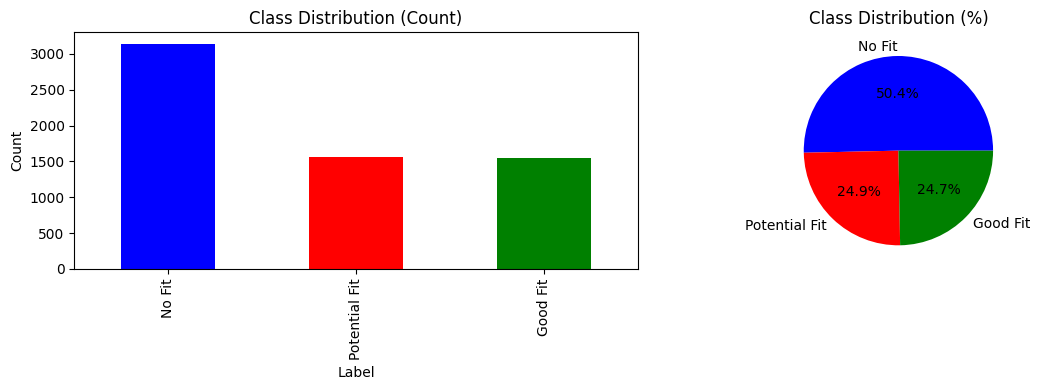


Imbalance Ratio: 2.04x


In [12]:
print(hf_train_df['label'].value_counts())
print("\nClass %:")
print(hf_train_df['label'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hf_train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['blue','red','green'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

hf_train_df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',colors=['blue','red','green'])
axes[1].set_title('Class Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

counts = hf_train_df['label'].value_counts()
ratio = counts.max() / counts.min()
print(f"\nImbalance Ratio: {ratio:.2f}x")

In [13]:
group_size=hf_train_df.groupby('job_description_text').size()

print(group_size.describe())
print("-"*50)
print("Groups with 1 sample:", (group_size == 1).sum())
print("Groups with 2 samples:", (group_size == 2).sum())
print("Groups with 3+ samples:", (group_size >= 3).sum())

count    280.000000
mean      22.285714
std       20.704193
min        1.000000
25%        7.000000
50%       14.500000
75%       29.250000
max      111.000000
dtype: float64
--------------------------------------------------
Groups with 1 sample: 3
Groups with 2 samples: 3
Groups with 3+ samples: 274


In [14]:
hf_train_df['resume_len'] = hf_train_df['resume_text'].apply(lambda x: len(x.split()))
hf_train_df['jd_len'] = hf_train_df['job_description_text'].apply(lambda x: len(x.split()))

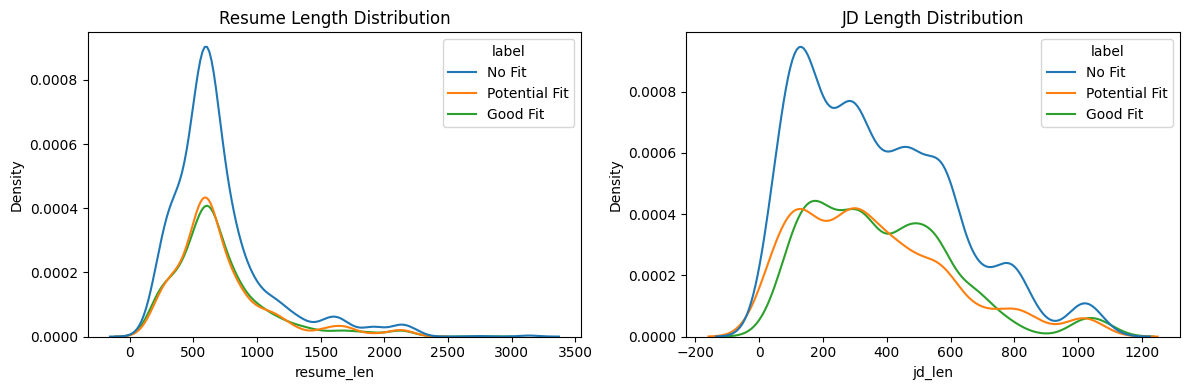

In [15]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

sns.kdeplot(data=hf_train_df,x='resume_len',hue='label',ax=axes[0])
axes[0].set_title('Resume Length Distribution')

sns.kdeplot(data=hf_train_df,x='jd_len',hue='label',ax=axes[1])
axes[1].set_title('JD Length Distribution')

plt.tight_layout()
plt.show()

In [16]:
hf_train_df.groupby('label')[['resume_len', 'jd_len']].mean()

,resume_len,jd_len
label,,
Good Fit,704.920882,384.646563
No Fit,707.776575,370.370146
Potential Fit,711.572622,360.785347


In [17]:
tech_aliases = {
    "javascript": ["js"],
    "typescript": ["ts"],
    "vue": ["vuejs"],
    "react": ["reactjs", "react.js"],
    "node": ["node.js", "nodejs"],
    "machine learning": ["ml"],
    "artificial intelligence": ["ai"],
    "natural language processing": ["nlp"],
    "computer vision": ["cv"],
    "kubernetes": ["k8s"],
    "amazon web services": ["aws"],
    "google cloud platform": ["gcp"],
    "user interface": ["ui"],
    "user experience": ["ux"],
    "database": ["db"],
    "data structures": ["dsa"],
    "react native": ["rn"],
    "tensorflow": ["tf"],
    "data science": ["ds"],
    "data analysis": ["da"],
    "devops": ["devop", "development operations"],
    "continuous integration": ["ci"],
    "continuous delivery": ["cd"],
    "object oriented programming": ["oop", "oops"],
    "docker": ["containerization"],
    "cloud computing": ["cloud"],
    "internet of things": ["iot"],
    "c++": ["c plus plus"],
    "c#": ["c sharp"],
    "python": ["py", "python language"],
    "sql":["mysql","postgresql","structured query language"]
}

In [18]:
def get_experience_section(text):
    text = text.lower()

    # common section headers
    start_keywords = ['experience', 'work history', 'professional experience']
    end_keywords = ['education', 'skills', 'projects', 'certifications']

    start_idx = -1
    for key in start_keywords:
        idx = text.find(key)
        if idx != -1:
            start_idx = idx
            break

    if start_idx == -1:
        return text  # fallback

    end_idx = len(text)
    for key in end_keywords:
        idx = text.find(key, start_idx)
        if idx != -1:
            end_idx = idx
            break

    return text[start_idx:end_idx]

In [19]:
def merge_and_calculate(intervals):
    # convert to months
    ranges = []
    for sy, sm, ey, em in intervals:
        start = sy * 12 + sm
        end = ey * 12 + em
        ranges.append((start, end))

    ranges.sort()

    merged = []
    for start, end in ranges:
        if not merged or merged[-1][1] < start:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)

    total_months = sum(end - start for start, end in merged)

    return round(total_months / 12, 2)

In [20]:
def is_valid_experience_context(line):
    invalid_words = ['education', 'expected', 'graduated', 'degree']
    return not any(word in line for word in invalid_words)

def extract_experience_better(text):
    exp_section = get_experience_section(text)
    lines = exp_section.split('\n')

    intervals = []

    for line in lines:
        if not is_valid_experience_context(line):
            continue

        # match date ranges
        match = re.search(
            r'(\d{1,2})[\/\-](\d{4})\s*(?:to|-)\s*(?:(\d{1,2})[\/\-](\d{4})|current|present)',
            line
        )

        if match:
            sm, sy, em, ey = match.groups()

            sm, sy = int(sm), int(sy)

            if ey:
                em, ey = int(em), int(ey)
            else:
                today = datetime.today()
                em, ey = today.month, today.year

            intervals.append((sy, sm, ey, em))

    return merge_and_calculate(intervals)

In [21]:
def extract_experience(text,is_resume=True):
  text=text.lower()

  matches_range=re.findall(r'(\d+)\s*-\s*(\d+)\s*(years|year|yrs|yr)',text)
  if matches_range:
    values=[(int(a)+int(b))/2 for a,b,_ in matches_range]
    return max(values)

  matches = re.findall(r'(\d+)\s*\+?\s*(years|year|yrs|yr)',text)
  if matches:
    values= [int(match[0]) for match in matches]
    return sum(values) if is_resume else max(values)

  return 0


In [22]:
hf_train_df['resume_exp']=hf_train_df['resume_text'].apply(lambda x:extract_experience(x))
hf_train_df['jd_exp']=hf_train_df['job_description_text'].apply(lambda x:extract_experience(x))

In [23]:
hf_train_df.head()

,resume_text,job_description_text,label,resume_len,jd_len,resume_exp,jd_exp
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit,794,559,0.75,9.0
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit,863,568,13.75,3.0
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit,872,438,8.33,6.0
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit,684,164,1.42,0.0
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit,1789,877,0.50,5.0


In [24]:
zero_exp=hf_train_df[hf_train_df['resume_exp']==0]
print(len(zero_exp))

1468


In [25]:
zero_sample=zero_exp['resume_text'].head(5)
for i,text in enumerate(zero_sample):
  print(f" Sample {i+1}:")
  print(text[:400])
  print()

 Sample 1:
SummaryA position in a company that will utilize my abilities in accounting and finance while providing the opportunity to increase my knowledge and experience.
SkillsAnalytical reasoningFinancial statement analysisAccount reconciliation expertComplex problem solvingEffective time managementStrong organizational skillsGeneral ledger accountingFlexible team playerStarBuilderSage Master BuilderDelte

 Sample 2:
SummaryI have studied Electrical Engineering with working experience in calibration, repair, service,maintenance and installation of Scientific instrument and solar products.
SkillsResults-orientedOperations managementClient-focusedExcel inRepair and ServiceProficiency incalibrationQuick learnerMultilingual( English, Punjabi, Hindi)Customer Support on call or by E-mail
Education and TrainingGED:El

 Sample 3:
SummaryISTQB certified QA Test Analyst/Payments SME with 8 years of experience in Testing of programs related to Banking and Finance (BFS) Payments Domain
*Profici

In [26]:
zero_exp_jd=hf_train_df[hf_train_df['jd_exp']==0]
print(len(zero_exp_jd))

1455


In [27]:
zero_sample_jd=zero_exp_jd['job_description_text'].head(1)
for i,text in enumerate(zero_sample_jd):
  print(f" Sample {i+1}:")
  print(text[:400])
  print()

 Sample 1:
Mizick Miller & Company, Inc. is looking for a dynamic individual to join our team!This is a great opportunity for the right candidate to work for a rapidly growing two office accounting firm located in Crawford & Wyandot counties.
Mizick Miller & Company, Inc. offers payroll, accounting, business consulting, agri-business consulting, and tax services to businesses, organizations, and individuals.



In [28]:
# %pip install gensim
# from gensim.models import Phrases
# from gensim.models.phrases import Phraser

Note: you may need to restart the kernel to use updated packages.


In [29]:
# def build_alias_pattern(alias_dict):
#     alias_to_key = {}
#     for key, values in alias_dict.items():
#         for v in values:
#             alias_to_key[v.lower()] = key

#     pattern = re.compile(
#         r'\b(' + '|'.join(re.escape(k) for k in alias_to_key.keys()) + r')\b',
#         flags=re.IGNORECASE
#     )
#     return pattern, alias_to_key

# def normalize_text(text, pattern, alias_to_key):
#     return pattern.sub(lambda m: alias_to_key[m.group(0).lower()], text)

In [30]:
def clean_text(text):
    text = text.lower()

    # 1. Remove URLs first (before special char removal breaks them)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 2. Remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # 3. Remove phone numbers (10+ digits)
    text = re.sub(r'\b\d{10,}\b', ' ', text)

    #remove numbers
    text = re.sub(r'\d+', ' ', text)

    # 4. Remove markdown markers but KEEP content inside
    text = re.sub(r'\*+|#+', ' ', text)          # ** ## markers
    text = re.sub(r'_{2,}', ' ', text)            # __ underline markdown

    # 5. Remove brackets but KEEP content inside (years/skills valuable)
    text = re.sub(r'[\[\]()]', ' ', text)

    # 6. Remove page numbers
    text = re.sub(r'page \d+', ' ', text)

    # 7. Remove special characters except spaces/./+/#
    text = re.sub(r'[^a-z0-9\s\+\#\.]', ' ', text)

    # 9. Remove extra whitespace — always LAST
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [31]:
# alias_pattern,alias_to_key=build_alias_pattern(tech_aliases)
# df['resume_text']=df['resume_text'].apply(lambda x:normalize_text(x,alias_pattern,alias_to_key))
# df['job_description_text']=df['job_description_text'].apply(lambda x:normalize_text(x,alias_pattern,alias_to_key))

In [32]:
hf_train_df['resume_text']=hf_train_df['resume_text'].apply(lambda x:clean_text(x))
hf_train_df['job_description_text']=hf_train_df['job_description_text'].apply(lambda x:clean_text(x))

In [36]:
all_skills=[key for key in tech_aliases.keys()]

In [37]:
import kagglehub

# path1 = kagglehub.dataset_download("arbazkhan971/allskillandnonskill")
path2 = kagglehub.dataset_download("meerawks/it-skills-from-jobs")

# df_skills1=pd.read_csv(path1+"/skills.csv")
df_skills2=pd.read_csv(path2+"/JobsDatasetProcessed.csv")

def normalize(skill):
    skill = str(skill).lower().strip()
    # Replace separators with space
    skill = re.sub(r'[/,_\-]+', ' ', skill)
    # Remove weird patterns like e.g.
    skill = re.sub(r'\be\.g\.\b', '', skill)
    # Remove extra spaces
    skill = re.sub(r'\s+', ' ', skill)

    return skill.strip()

def split_skills(skill):
    return re.split(r'\bor\b|/|,|and|___|__', skill)

def extract_skills(skill):
    raw = str(skill).lower()
    parts = split_skills(raw)

    cleaned = []
    for p in parts:
        p = normalize(p)
        if p:
            cleaned.append(p)

    return cleaned

def is_valid_skill(skill):
    if len(skill) < 2:
        return False
    if len(skill) > 40:
        return False
    if skill.isdigit():
        return False
    return True


def extract_skills_from_row(df,col):
  skills_set = set()
  for skills in df[col].dropna():
      extracted = extract_skills(skills)
      for s in extracted:
          if is_valid_skill(s):
              skills_set.add(s)
  return skills_set

skills_set2=extract_skills_from_row(df_skills2,"IT Skills")
# skills_set1 = extract_skills_from_row(df_skills1,"Skill")
# total_skill = skills_set1.union(skills_set2)
# total_skill=skills_set2

all_skills.extend(skills_set2)



In [38]:
all_skills=set(all_skills)

In [40]:
import spacy

try:
    spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    !python -m spacy download en_core_web_md --quiet
    import spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 44.6 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [39]:
def build_phrase_matcher(nlp, alias_dict,all_skills):
    matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
    patterns=[]
    skill_map={}
    # Add alias dict
    for key, values in alias_dict.items():
        patterns.append(nlp.make_doc(key))
        skill_map[key.lower()]=key
        for v in values:
            patterns.append(nlp.make_doc(v))
            skill_map[v.lower()]=key

     # 2. Add remaining skills (from Kaggle)
    for skill in all_skills:
        if skill.lower() not in skill_map:
            patterns.append(nlp.make_doc(skill))
            skill_map[skill.lower()] = skill


    matcher.add("SKILLS", patterns)
    return matcher,skill_map


def single_pass_pipeline(texts, matcher,skill_map, nlp):
    processed_texts = []
    print("Applying alias normalization and phrase matching...")


    print("Processing documents with spaCy...")
    for doc in tqdm(nlp.pipe(texts, batch_size=200,n_process=2), total=len(texts)):
        raw_matches = matcher(doc)
        spans = [(match_id, start, end) for match_id, start, end in raw_matches]
        filtered_spans = filter_spans([doc[start:end] for _, start, end in spans])

        span_dict = {}
        match_map = {(start, end): match_id for match_id, start, end in spans}

        for span in filtered_spans:
            match_id = match_map[(span.start, span.end)]
            normalize_skill=skill_map.get(span.text.lower(),span.text.lower())
            span_dict[span.start] = (span.end, normalize_skill)

        tokens = []
        i = 0

        while i < len(doc):
            if i in span_dict:
                end_idx, label = span_dict[i]
                tokens.append(label.replace(" ","_"))
                i = end_idx
                continue

            token = doc[i]

            if (token.is_stop or token.is_punct or token.is_space or
                token.like_url or token.like_email):
                i += 1
                continue

            if token.pos_ not in ['NOUN', 'VERB', 'ADJ', 'PROPN']:
                i += 1
                continue

            lemma = token.lemma_.lower()

            if len(lemma) > 2 :
                tokens.append(lemma)

            i += 1

        processed_texts.append(" ".join(tokens))

    return processed_texts


def preprocess_pipeline(texts, alias_dict):
    nlp = spacy.load("en_core_web_md",disable=["parser", "ner"])
    print("Building phrase matcher...")
    matcher,skill_map =build_phrase_matcher(nlp, alias_dict,all_skills)
    return single_pass_pipeline(texts,matcher,skill_map,nlp)


In [41]:
resume_processed = preprocess_pipeline(hf_train_df['resume_text'].tolist(), tech_aliases)

In [42]:
job_description_processed = preprocess_pipeline(hf_train_df['job_description_text'].tolist(), tech_aliases)

In [43]:
import pickle
preprocessed_directory_path = '/kaggle/input/datasets/ankeshwar004/preprocessed'
os.makedirs(preprocessed_directory_path,exist_ok=True)

In [44]:
# pickle.dump(resume_processed,open(preprocessed_directory_path + '/resume.pkl','wb'))
# pickle.dump(job_description_processed, open(preprocessed_directory_path + '/jd.pkl','wb'))

In [45]:
# resume_processed=pickle.load(open(preprocessed_directory_path + '/resume.pkl','rb'))
# job_description_processed=pickle.load(open(preprocessed_directory_path + '/jd.pkl','rb'))

In [46]:
hf_train_df['resume_clean']=resume_processed
hf_train_df['jd_clean']=job_description_processed
hf_train_df.head()

,resume_text,job_description_text,label,resume_len,jd_len,resume_exp,jd_exp,resume_clean,jd_clean
0,summaryhighly motivated sales associate with e...,net source inc. is an award winning total work...,No Fit,794,559,0.75,9.0,motivate sales associate extensive customer_se...,net source inc award win total workforce solut...
1,professional summarycurrently working with cat...,at salas obrien we tell our clients that were ...,No Fit,863,568,13.75,3.0,professional work caterpillar as contract empl...,salas obrien tell clients engineer impact pass...
2,summaryi started my construction career in jun...,schweitzer engineering laboratories sel infras...,No Fit,872,438,8.33,6.0,summaryi start construction career june jackso...,schweitzer engineering laboratory sel infrastr...
3,summarycertified electrical foremanwith thirte...,mizick miller company inc. is looking for a dy...,No Fit,684,164,1.42,0.0,summarycertifie electrical foremanwith year ex...,mizick miller company inc look dynamic individ...
4,summarywith extensive experience in business r...,life at capgemini capgemini supports all aspec...,No Fit,1789,877,0.50,5.0,summarywith extensive experience business requ...,life capgemini capgemini support aspect change...


In [48]:
label_map = {
    "No Fit": 0,
    "Potential Fit": 1,
    "Good Fit": 2
}

hf_train_df['label'] = hf_train_df['label'].map(label_map)

In [49]:
hf_train_df=hf_hf_train_df.copy()

0       0
1       0
2       0
3       0
4       0
       ..
6236    2
6237    2
6238    2
6239    2
6240    2
Name: label, Length: 6240, dtype: int64

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupShuffleSplit

from scipy.stats import spearmanr
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


In [51]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GroupKFold

from xgboost import XGBClassifier


In [52]:
def skill_overlap(resume_texts, jd_texts, all_skills):
    rows = []

    for res, jd in zip(resume_texts, jd_texts):
        res_tokens = set(res.split())
        jd_tokens = set(jd.split())

        res_skills = res_tokens & all_skills
        jd_skills = jd_tokens & all_skills

        matched = res_skills & jd_skills

        match_count = len(matched)
        jd_count = len(jd_skills)
        res_count = len(res_skills)

        jd_coverage = match_count / jd_count if jd_count > 0 else 0

        # ---- CAPPED Precision (no penalty for extra useful skills) ----
        precision_capped = match_count / min(res_count, jd_count) if min(res_count, jd_count) > 0 else 0


        rows.append([
            match_count,
            # jd_coverage,
            precision_capped,

        ])

    return np.array(rows)

In [53]:
def map_score(df, scores, relevant_threshold=1):
    df = df.copy()
    df['score'] = scores

    average_precisions = []

    for jd, group in df.groupby('job_description_text'):

        group = group.sort_values('score', ascending=False)

        num_relevant = 0
        precision_sum = 0

        total_relevant = (group['label'] >= relevant_threshold).sum()

        if total_relevant == 0:
            continue

        for rank, (_, row) in enumerate(group.iterrows(), start=1):

            if row['label'] >= relevant_threshold:

                num_relevant += 1

                precision_at_k = num_relevant / rank

                precision_sum += precision_at_k

        ap = precision_sum / total_relevant

        average_precisions.append(ap)

    return np.mean(average_precisions) if average_precisions else 0.0

In [54]:
def mrr(df, scores, relevant_threshold=1):
    df = df.copy()
    df['score'] = scores

    reciprocal_ranks = []

    for jd, group in df.groupby('job_description_text'):

        group = group.sort_values('score', ascending=False)

        rr = 0

        for rank, (_, row) in enumerate(group.iterrows(), start=1):

            if row['label'] >= relevant_threshold:
                rr = 1 / rank
                break

        reciprocal_ranks.append(rr)

    return np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0

In [55]:
def top_k_accuracy(df, scores, k=3):
    df = df.copy()
    df['score'] = scores

    correct,total=0,0

    for jd, group in df.groupby('job_description_text'):
        if 2 not in group['label'].values:
            continue

        group = group.sort_values('score', ascending=False)
        top_k = group.head(k)

        if (top_k['label'] >= 1).any():
            correct += 1
        total += 1

    return correct / total if total>0 else 0

In [56]:
def ndcg(df,scores):
  df = df.copy()
  df['score']=scores

  ndcg_scores = []
  for jd, group in df.groupby('job_description_text'):
      if len(group) > 1:
          y_true_group = group['label'].values.reshape(1, -1)
          y_pred_group = group['score'].values.reshape(1, -1)
          ndcg_scores.append(ndcg_score(y_true_group, y_pred_group,k=min(10,len(group))))
  return np.mean(ndcg_scores) if ndcg_scores else 0.0

In [57]:
def corr_score(df,scores):
  df=df.copy()
  df['score']=scores
  corr_list = []

  for jd,group in df.groupby('job_description_text'):
    if len(group['label'].unique())>1:
      corr,_=spearmanr(group['label'],group['score'])

      if not np.isnan(corr):
        corr_list.append(corr)

  return np.mean(corr_list)

In [84]:
def train_and_eval_rank(X_train,X_test,y_train,y_test,train_df,test_df):
  model=XGBRanker(objective='rank:ndcg',learning_rate=0.05,max_depth=7, n_estimators=300,
                  subsample=0.8,colsample_bytree=0.8)

  group_train=train_df.groupby('job_description_text').size().to_list()
  model.fit(X_train,y_train,group=group_train)
  scores=model.predict(X_test)

  spearman_score=corr_score(test_df,scores)
  topk_score=top_k_accuracy(test_df,scores,k=3)
  ndcg_val=ndcg(test_df,scores)
  mrr_score=mrr(test_df,scores,1)  
  map_val=map_score(test_df,scores,1)  

  print("Spearman:", spearman_score)
  print("Top-3 Accuracy:", topk_score)
  print("NDCG:", ndcg_val)
  print("MRR:", mrr_score)
  print("MAP:", map_val)

  feature_importance=model.feature_importances_

  return {
    "feature_importance":feature_importance,
    "spearman_score":spearman_score,
    "topk_score":topk_score,
    "ndcg_val":ndcg_val, 
    "mrr_score":mrr_score,
    "map_val":map_val
  }


In [59]:
gss = GroupShuffleSplit(test_size=0.2,random_state=42)

train_idx,val_idx = next(gss.split(hf_train_df,groups=hf_train_df['job_description_text']))

train_df=df_new.iloc[train_idx]
val_df=df_new.iloc[val_idx]

In [60]:
train_df = train_df.sort_values('job_description_text').reset_index(drop=True)
val_df = val_df.sort_values('job_description_text').reset_index(drop=True)

In [61]:
y_train=train_df['label']
y_val=val_df['label']

In [62]:
len(y_train), len(y_val)

(5234, 1006)

# ------BASELINE MODEL (TF-IDF +SVD)------

In [63]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    stop_words='english'
)

vectorizer.fit(pd.concat([train_df['resume_clean'],train_df['jd_clean']]))
X_train_resume = vectorizer.transform(train_df['resume_clean'])
X_train_jd = vectorizer.transform(train_df['jd_clean'])

X_val_resume = vectorizer.transform(val_df['resume_clean'])
X_val_jd = vectorizer.transform(val_df['jd_clean'])

In [64]:
train_sim = cosine_similarity(X_train_resume, X_train_jd).diagonal().reshape(-1,1)
val_sim = cosine_similarity(X_val_resume, X_val_jd).diagonal().reshape(-1,1)

In [65]:
skill_overlap_train=skill_overlap(train_df['resume_clean'],train_df['jd_clean'],all_skills)
skill_overlap_val=skill_overlap(val_df['resume_clean'],val_df['jd_clean'],all_skills)


In [66]:
exp_gap_train=train_df['resume_exp']-train_df['jd_exp']
exp_gap_val=val_df['resume_exp']-val_df['jd_exp']

exp_match_train=train_df['resume_exp']/(train_df['jd_exp']+1)
exp_match_val=val_df['resume_exp']/(val_df['jd_exp']+1)

exp_enough_train=train_df['resume_exp']>=train_df['jd_exp'].astype(int)
exp_enough_val=val_df['resume_exp']>=val_df['jd_exp'].astype(int)

In [67]:
X_train_features = np.hstack([
    train_sim,
    skill_overlap_train,
    exp_gap_train.to_numpy().reshape(-1,1),
])

X_val_features = np.hstack([
    val_sim,
    skill_overlap_val,
    exp_gap_val.to_numpy().reshape(-1,1),
])

In [68]:
pd.DataFrame(X_train_features).corr()

,0,1,2,3
0,1.000000,0.453611,0.396497,-0.117607
1,0.453611,1.000000,0.323785,-0.217420
2,0.396497,0.323785,1.000000,-0.034074
3,-0.117607,-0.217420,-0.034074,1.000000


In [69]:
X_train_interaction = X_train_resume.multiply(X_train_jd)
X_val_interaction = X_val_resume.multiply(X_val_jd)

In [70]:
svd = TruncatedSVD(n_components=30, random_state=42)
X_train_svd = svd.fit_transform(X_train_interaction)
X_val_svd = svd.transform(X_val_interaction)

X_train_combine = np.hstack([X_train_svd, X_train_features])
X_val_combine = np.hstack([X_val_svd, X_val_features])

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_combine)
X_val_final = scaler.transform(X_val_combine)


In [71]:
models={"SVM":SVC(class_weight="balanced",probability=True),
        "LogisticRegression":LogisticRegression(class_weight="balanced",max_iter=1000),
        "RandomForest": RandomForestClassifier(n_estimators=200,class_weight="balanced", random_state=42),
        "XGB":XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.1)}

In [72]:
def train_and_eval(X_train, X_test, y_train, y_test, model, df):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  print("Unique predictions:", set(y_pred))
  print("Variance:", np.var(y_pred))

  y_prob = model.predict_proba(X_test)
  scores=y_prob[:,2]

  corr, _ = spearmanr(y_test, scores)
  print("Spearman Correlation:", corr)

  print(classification_report(y_test, y_pred))

  top3 = top_k_accuracy(df,scores,k=3)
  print("Top-3 Accuracy:", top3)

  ndcg_score=ndcg(df,scores)
  print("Ndgc scoreL",ndcg_score)

In [73]:
for name, model_obj in models.items():
    print(f"\n--- Evaluating Model: {name} ","-"*50)
    train_and_eval(X_train_final, X_val_final, y_train, y_val, model_obj, val_df)


--- Evaluating Model: SVM  --------------------------------------------------
Unique predictions: {np.int64(0), np.int64(1), np.int64(2)}
Variance: 0.5620639977234013
Spearman Correlation: 0.26223274012123465
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       519
           1       0.40      0.36      0.38       220
           2       0.38      0.22      0.28       267

    accuracy                           0.55      1006
   macro avg       0.47      0.46      0.46      1006
weighted avg       0.52      0.55      0.52      1006

Top-3 Accuracy: 0.9259259259259259
Ndgc scoreL 0.6934430108891484

--- Evaluating Model: LogisticRegression  --------------------------------------------------
Unique predictions: {np.int64(0), np.int64(1), np.int64(2)}
Variance: 0.6093221980245762
Spearman Correlation: 0.11199334954899967
              precision    recall  f1-score   support

           0       0.63      0.74      0.68       519
         

In [74]:
from xgboost import XGBRanker

In [85]:
print("Evaluating on Full Validation Df")
metrics=train_and_eval_rank(
    X_train_final,X_val_final,
    y_train,y_val,
    train_df,val_df)

imp_feature=metrics['feature_importance']

Evaluating on Full Test Df
Spearman: 0.33399474016189445
Top-3 Accuracy: 0.8888888888888888
NDCG: 0.6720742592839342
MRR: 0.6947916666666666
MAP: 0.713858548351475


In [86]:
cosine_imp=imp_feature[0]
skill_overlap_imp=imp_feature[1:4]
exp_gap_imp=imp_feature[4]
svd_imp=imp_feature[5:].sum()

In [77]:
print("Cosine:", cosine_imp)
print("Skill_overlap:", skill_overlap_imp.sum())
print("Exp_gap:",exp_gap_imp)
print("SVD (semantic):", svd_imp)

Cosine: 0.056449957
Skill_overlap: 0.09002297
Exp_gap: 0.026295811
SVD (semantic): 0.82723117


In [87]:
kf=GroupKFold(n_splits=5)
ndcg_scores,spearman_scores,topk_scores,mrr_scores,map_scores=[],[],[],[],[]

for fold, (train_split, val_split) in enumerate(
    kf.split(X_train_final, y_train, groups=train_df['job_description_text'])):

    print(f"for {fold+1}:\n")
    metrics=train_and_eval_rank(
        X_train_final[train_split],X_train_final[val_split],
        y_train.iloc[train_split],y_train.iloc[val_split],
        train_df.iloc[train_split],train_df.iloc[val_split])

    spearman_scores.append(metrics['spearman_score'])
    topk_scores.append(metrics['topk_score'])
    ndcg_scores.append(metrics['ndcg_val'])
    map_scores.append(metrics['map_val'])
    mrr_scores.append(metrics['mrr_score'])
    print("-"*100)

print(f"\nCV NDCG: {np.mean(ndcg_scores):.4f} ± {np.std(ndcg_scores):.4f}")
print(f"CV Spearman: {np.mean(spearman_scores):.4f} ± {np.std(spearman_scores):.4f}")
print(f"CV Top-3 Accuracy: {np.mean(topk_scores):.4f} ± {np.std(topk_scores):.4f}")
print(f"CV MAP: {np.mean(map_scores):.4f} ± {np.std(map_scores):.4f}")
print(f"CV MRR: {np.mean(mrr_scores):.4f} ± {np.std(mrr_scores):.4f}")



for 1:

Spearman: 0.3656523952981423
Top-3 Accuracy: 0.9444444444444444
NDCG: 0.7586461025364439
MRR: 0.8064814814814816
MAP: 0.7797409836362976
----------------------------------------------------------------------------------------------------
for 2:

Spearman: 0.32267613394582223
Top-3 Accuracy: 0.9473684210526315
NDCG: 0.6521569365098693
MRR: 0.6699999999999999
MAP: 0.7182355164825698
----------------------------------------------------------------------------------------------------
for 3:

Spearman: 0.3059115670609911
Top-3 Accuracy: 0.8888888888888888
NDCG: 0.6098127685157966
MRR: 0.6440740740740741
MAP: 0.7227135319340356
----------------------------------------------------------------------------------------------------
for 4:

Spearman: 0.2995068244522542
Top-3 Accuracy: 0.9444444444444444
NDCG: 0.5738348337138787
MRR: 0.6306818181818182
MAP: 0.752724553386508
----------------------------------------------------------------------------------------------------
for 5:

Spearman

# ----IMPROVE MODEL-----

In [81]:
import torch

if torch.cuda.is_available():
  device='cuda'
else:
  device='cpu'

print(f"Device:{device}")

Device:cpu


In [89]:
from sentence_transformers import CrossEncoder,InputExample
from sentence_transformers.cross_encoder.evaluation import CERerankingEvaluator

from torch.utils.data import DataLoader
from transformers import AutoTokenizer


In [ ]:
gss=GroupShuffleSplit(test_size=0.15,random_state=42)

train_idx,val_idx=next(gss.split(train_df,groups=train_df['jd_clean']))

train_split,val_split=train_df.iloc[train_idx],train_df.iloc[val_idx]

print(len(train_split),len(val_split))

In [90]:
label_to_score = {0: 0.0, 1: 0.6, 2: 1.0} #1 map to 0.6 bec in resume ranking maybe is more closs to confirm close than no job acc to jd


cross_train_examples=[
    InputExample(texts=[j,r],label=float(label_to_score[l]))
    for r,j,l in zip(train_split['resume_clean'],train_split['jd_clean'],train_split['label'])
]

print(f"total training example:{len(cross_train_examples)}")

total training example:4423


In [91]:
cross_train_dataloader=DataLoader(cross_train_examples,shuffle=True,batch_size=16)

In [92]:
cross_encoder_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2',num_labels=1,device=device, max_length=384)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [93]:
def evaluate_cross_encoder_model(model,val_df):
    val_pairs=list(zip(val_df['jd_clean'],val_df['resume_clean']))

    scores=model.predict(val_pairs,batch_size=16,show_progress_bar=False)

    spearman_score=corr_score(val_df,scores)
    topk_score=top_k_accuracy(val_df,scores,k=3)
    ndcg_val=ndcg(val_df,scores)

    return {
    "spearman": spearman_score,
    "topk": topk_score,
    "ndgc": ndcg_val
    }


In [94]:
epochs=4
best_score=float('-inf')
print("\tTraining Phase")
for epoch in range(1,epochs+1):
    print(f"Epoch: {epoch}----------")

    cross_encoder_model.fit(train_dataloader=cross_train_dataloader,epochs=1,
                             warmup_steps=int(len(cross_train_dataloader) * epochs * 0.1),
                            show_progress_bar=True)

    scores=evaluate_cross_encoder_model(cross_encoder_model,val_split)

    print(f"Spearman Score:{scores['spearman']}")
    print(f"Top 3 score:{scores['topk']}")
    print(f"NDGC Score:{scores['ndgc']}")

    final_score=0.6*scores['ndgc']+0.3*scores['topk']+0.1*scores['spearman']

    if final_score>best_score:
        best_score=final_score
        cross_encoder_model.save("cross_encoder_model")
    

print("\tInference Phase")

val_pairs=list(zip(val_df['jd_clean'],val_df['resume_clean']))

scores=cross_encoder_model.predict(val_pairs,batch_size=16,show_progress_bar=False)

ranked_result=[]
val_df_new=val_df.copy()
val_df_new['score']=scores


for jd,group in val_df_new.groupby('jd_clean'):
    ranked_group=group.sort_values("score",ascending=False)
    ranked_result.append(ranked_group)

final_rank_df=pd.concat(ranked_result)

	Training Phase
Epoch: 1----------


Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 384). Running this sequence through the model will result in indexing errors


Step,Training Loss


KeyboardInterrupt: 

In [ ]:
spearman_score=corr_score(val_df,scores)
topk_score=top_k_accuracy(val_df,scores,k=3)
ndcg_val=ndcg(val_df,scores)
mrr_score=mrr(val_df,scores)
map_val=map_score(val_df,scores)

print(f"Spearman Score:{spearman_score}")
print(f"Top 3 score:{topk_score}")
print(f"NDGC Score:{ndcg_val}")
print(f"NDGC Score:{mrr_score}")
print(f"NDGC Score:{map_val}")

In [ ]:
i=0
for jd,group in final_rank_df.groupby('jd_clean'):
    if(len(group)>2 and len(group)<10):
        print("Job Description:\n",jd[:300])
        print(group[['label','score']])
        i+=1
        if i==3:
            break

In [ ]:
from sentence_transformers import SentenceTransformer,losses,util
bi_encoder= SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2',device=device)


In [ ]:
bi_train_examples=[
    InputExample(texts=[j,r],label=float(label_to_score[l]))
    for r,j,l in zip(train_split['resume_clean'],train_split['jd_clean'],train_split['label'])
]

bi_train_dataloader=DataLoader(bi_train_examples,shuffle=True,batch_size=32)

bi_train_loss=losses.CoSENTLoss(bi_encoder)

In [ ]:
bi_encoder.fit(train_objectives=[(bi_train_dataloader,bi_train_loss)],
              epochs=4,warmup_steps=int(len(bi_train_dataloader) * epochs * 0.1),
              show_progress_bar=True,output_path="bi_encoder_resume_model")

In [ ]:

train_resume_emb= bi_encoder.encode(train_split['resume_clean'].tolist(),
                              batch_size=32,convert_to_tensor=True,
                              show_progress_bar=True)

val_resume_emb= bi_encoder.encode(val_df['resume_clean'].tolist(),
                              batch_size=32,convert_to_tensor=True,
                              show_progress_bar=True)

In [ ]:
train_resume_emb.shape,val_resume_emb.shape

In [ ]:
bi_ndcg_list = []

cross_ndcg_list= []

bi_spearman_list = []
cross_spearman_list = []

bi_topk_correct = 0
cross_topk_correct = 0

total_jds=0

K=3

test_resume_texts = val_df["resume_clean"].tolist()

In [ ]:
for jd,group in val_df.groupby('jd_clean'):

    if len(group)<2:
        continue
        
    group_label=group[['resume_clean','label']].drop_duplicates()
    label_map=dict(zip(group['resume_clean'],group['label']))

    # Stage 1 — Bi-Encoder retrieval (top-50)

    jd_emb=bi_encoder.encode(jd,convert_to_tensor=True)
    
    hits=util.semantic_search(jd_emb, val_resume_emb, top_k=50)
    hits=hits[0]

    retrieval_rows = []
    for hit in hits:
        idx=hit["corpus_id"]
        resume_text=val_resume_texts[idx]
        label=label_map.get(resume_text, None)
        if label is None:
            continue
        retrieval_rows.append({
            "resume_text":resume_text,
            "bi_score": float(hit["score"]),
            "label": label
        })
    retrieval_df=pd.DataFrame(retrieval_rows)

    if len(retrieval_df)<2:
        continue

    bi_scores=retrieval_df['bi_score'].values
    bi_labels=retrieval_df['label'].values

    # NDGC
    bi_ndcg=ndcg_score(bi_labels.reshape(1,-1),bi_scores.reshape(1,-1),k=min(10,len(retrieval_df)))
    bi_ndcg_list.append(bi_ndcg)
    
    # Spearman
    if len(np.unique(bi_labels)) > 1:
        corr, _ = spearmanr(bi_labels, bi_scores)
        if not np.isnan(corr):
            bi_spearman_list.append(corr)

    # Top-K accuracy
    if 2 in bi_labels:
        retrieval_df_sorted = retrieval_df.sort_values("bi_score", ascending=False)
        if (retrieval_df_sorted.head(K)['label'] == 2).any():
            bi_topk_correct += 1
            
    # Stage 2 — Cross-Encoder reranking (on bi-encoder top-50)

    pairs=list(zip([jd]*len(retrieval_df),retrieval_df['resume_text']))

    cross_scores=cross_encoder_model.predict(pairs,batch_size=16)

    rerank_df=retrieval_df.copy()
    rerank_df['cross_score']=cross_scores
    rerank_df=rerank_df.sort_values("cross_score",ascending=False).reset_index(drop=True)

    cross_scores=rerank_df['cross_score'].values
    cross_labels=rerank_df['label'].values

    # NDGC
    cross_ndcg=ndcg_score(cross_labels.reshape(1,-1),cross_scores.reshape(1,-1),
                          k=min(10,len(rerank_df)))
    cross_ndcg_list.append(cross_ndcg)
    
    # Spearman
    if len(np.unique(cross_labels)) > 1:
        corr, _ = spearmanr(cross_labels,cross_scores)
        if not np.isnan(corr):
            cross_spearman_list.append(corr)

    # Top-K accuracy
    if 2 in cross_labels:
        rerank_df_sorted = rerank_df.sort_values("cross_score", ascending=False)
        if (rerank_df_sorted.head(K)["label"] == 2).any():
            cross_topk_correct += 1
        total_jds+=1
        
            
    
print("\n" + "=" * 60)
print("FINAL TWO-STAGE RETRIEVAL RESULTS")

print("=" * 45)
print(f"{'Metric':<25} {'Bi-Encoder':>8}   {'Cross-Encoder':>13}")
print("=" * 45)
print(f"{'NDCG@10':<25} {np.mean(bi_ndcg_list):>8.4f}   {np.mean(cross_ndcg_list):>13.4f}")
print(f"{'Spearman r':<25} {np.mean(bi_spearman_list):>8.4f}   {np.mean(cross_spearman_list):>13.4f}")
print(f"{'Top-{K} Accuracy':<25} {bi_topk_correct/total_jds:>8.4f}   {cross_topk_correct/total_jds:>13.4f}")
print("=" * 45)

    
    


In [ ]:
# eval_df=test_df.copy()
# eval_df['score']=bert_scores

In [ ]:
# print("\nScore spread within groups:")
# spreads = []
# for jd, group in eval_df.groupby('job_description_text'):
#     if len(group) > 1:
#         spreads.append(group['score'].max() - group['score'].min())

# print(f"Mean spread: {np.mean(spreads):.4f}")
# print(f"% groups with spread < 0.1:"f"{(np.array(spreads) < 0.1).mean():.2%}")

In [ ]:
# # Find potentially mislabeled samples
# # Good Fit resumes with very low scores
# suspicious = eval_df[
#     (eval_df['label'] == 2) &
#     (eval_df['score'] < -0.3)
# ][['resume_clean', 'job_description_text', 'score', 'label']]

# print(f"Good Fit resumes scoring below -0.3: {len(suspicious)}")
# print("\nSample suspicious resumes:")
# for _, row in suspicious.head(5).iterrows():
#     print(f"Score: {row['score']:.3f}")
#     print(f"Resume: {row['resume_clean'][:200]}\n")

In [ ]:
# # Find a JD with all 3 label types
# good_jds = []
# for jd, group in eval_df.groupby('job_description_text'):
#     if set(group['label'].values) == {0, 1, 2}:
#         good_jds.append(jd)

# print(f"JDs with all 3 label types: {len(good_jds)}")

# # Sample one of these
# sample_jd = good_jds[0]
# group = eval_df[eval_df['job_description_text'] == sample_jd].copy()
# group = group.sort_values('score', ascending=False)

# label_name = {0: "No Fit", 1: "Potential Fit", 2: "Good Fit"}
# print(f"\nJD: {sample_jd[:200]}")
# print("\n--- Ranked Resumes ---")
# for rank, (_, row) in enumerate(group.iterrows(), 1):
#     print(f"Rank {rank} | Label:  {label_name[row['label']]} "
#           f"| Score: {row['score']:.4f}")
#     print(f"Resume: {row['resume_clean'][:150]}\n")